In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

Starobinsky potential:
$$
V(\phi)=V_0 (1-e^{-\sqrt{\frac{2}{3}}\phi})^2 \\
V_{,\phi} = 2\sqrt{\frac{2}{3}} exp(-\sqrt{\frac{2}{3}}\phi) \sqrt{V_0 V}
$$

### Defining a system of equations

Here I use the Raychaudhuri, KG and continuity equations listed below; redefined using a scalar field model of the universe $\rho_\phi$ and $P_\phi$ also below. From these, I then define some dimensionless variables from the Hubble equation for kinetic energy, potential energy, curvature and barotropic density. 

$$
H^2 = \frac{1}{3} (\frac{\dot{\phi}^2}{2}+ V(\phi))
$$
$$
\rho_\phi = \frac{\dot{\phi}^2}{2} + V(\phi) $$
$$
P = \frac{\dot{\phi}^2}{2} - V(\phi)
$$

The system of equations used are: 
$$
\dot{H}=-\frac{\dot{\phi}^2}{2}~~~~ Raychaudhuri~Equation \\
\dot{\rho} =-3H {\dot\phi}^2 = -\frac{\dot{\phi}^4}{2} -\dot{\phi}^2 V~~~~ Continuity~Equation \\
\ddot{\phi} +3H\dot{\phi} +dV/d\phi = \frac{\dot{\phi}^3}{2} +\dot{\phi}V +2\sqrt{\frac{2}{3}}exp(-\sqrt{\frac{2}{3}}\phi) \sqrt{V_0 V}~~~~Klien-Gordon~~Equation 
$$

which will be transformed using dimensionless variables:
$$\eta =\sqrt{V_0}t \\
\Phi = \frac{\phi}{1+\phi^2} \\
\psi = \frac{\dot{\phi}}{\sqrt{V_0}} \\
\Psi = \frac{\psi}{1+\psi^2}\\
y=\frac{H}{\sqrt{V_0}}\\
Y=\frac{y}{\sqrt{1+y^2}}\\
$$ 
So the Friedmann equation becomes:
$$
\frac{Y}{\sqrt{1-Y^2}} =\pm \sqrt{\frac{1}{3}\left[ 1-exp(-\sqrt{\frac{2}{3}}\frac{\Phi^2}{\sqrt{1-\Phi^2}})  \right]^2 +\frac{\Psi^2}{6(1-\Psi^2)}    }\\ \\
Y = \pm \sqrt{\frac{\frac{1}{3}\left[ 1-exp(-\sqrt{\frac{2}{3}}\frac{\Phi^2}{\sqrt{1-\Phi^2}})  \right]^2 +\frac{\Psi^2}{6(1-\Psi^2)}   }{1+\frac{1}{3}\left[ 1-exp(-\sqrt{\frac{2}{3}}\frac{\Phi^2}{\sqrt{1-\Phi^2}})  \right]^2 +\frac{\Psi^2}{6(1-\Psi^2)}    }}

$$
in dimensionless variable terms.


The dynamical system then simplifies down to 2D:
$$
\Phi' = (1-\Phi^2)^\frac{3}{2} \frac{\Psi}{\sqrt{1-\Psi^2}} \\

\Psi' = (1-\Psi^2)^\frac{3}{2} \left[ -3 \frac{\Psi}{\sqrt{1-\Psi^2}}* \frac{Y}{\sqrt{1-Y^2}}     -2\sqrt{\frac{2}{3}}*exp(-\sqrt{\frac{2}{3}} \frac{\Phi}{\sqrt{1-\Phi^2}}) (1- exp( -\sqrt{\frac{2}{3}} \frac{\Phi}{\sqrt{1-\Phi^2}}))
\right]

$$

Detected fixed points: [array([-0., -0.]), array([0.998812, 0.      ]), array([0.998989, 0.      ]), [np.float64(1.0), np.int64(0)]]
Fixed points (-0.0,-0.0)
Eigen Values: [6.12371517e-07+1.15469996j 6.12371517e-07-1.15469996j]
Type=Spiral
Stability=Repeller

Fixed points (0.998812,0.0)
Eigen Values: [-4.16306694e-08  1.73204873e+00]
Type=node
Stability=saddle

Fixed points (0.998989,0.0)
Eigen Values: [-1.01893536e-08  1.73204877e+00]
Type=node
Stability=saddle



/tmp/ipykernel_2801/1724423487.py:171: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


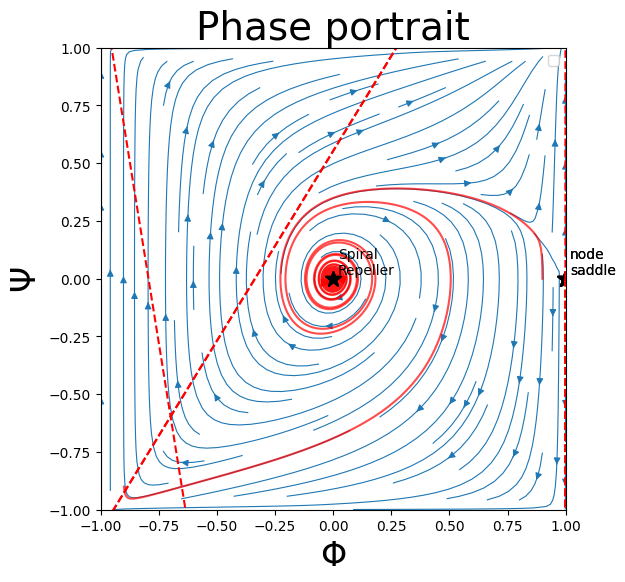

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import root

phi = np.linspace(0,5,100)
V0=1
V=V0*(1- np.exp(-(2/3)**0.5 *phi))**2
A = -1.0  #change to -1 if contracting universe, also change ICs

# dPhi and dPsi are the equations from above.

def dynamicsStateSpace(t,X):
    Phi,Psi = X
    Phi = np.clip(Phi, -0.999, 0.999)
    Psi = np.clip(Psi, -0.999, 0.999)
    Y= A * np.sqrt( (1/6 * Psi**2 /(1-Psi**2 +1e-6) +  1/3 *(1-np.exp(-(2/3)**0.5 *Phi/(1-Phi**2 +1e-6)**0.5 ))**2 )  / (1+ (1/6 * Psi**2 /(1-Psi**2 +1e-6) +  1/3 *(1-np.exp(-(2/3)**0.5 *Phi/(1-Phi**2 +1e-6)**0.5 ))**2 ) ))
    dPhi = (1-Phi**2)**(3/2) * Psi/((1-Psi**2 + 1e-6)**0.5)  
    dPsi = (1-Psi**2)**(3/2) * (  -3*Psi/(1-Psi**2 +1e-6)**0.5 *Y/(1-Y**2 +1e-6)**0.5 -2*(2/3)**0.5 *np.exp(-(2/3)**0.5 *Phi/(1-Phi**2 +1e-6)**0.5 ) *(1- np.exp(-(2/3)**0.5 *Phi/(1-Phi**2 +1e-6)**0.5)) )
    return [dPhi, dPsi]



simulationTime=np.linspace(0,50,600)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory

def traj(Phi0, Psi0, t_span=(50, -50)): # change to forward time -50,50 for expanding and 50,-50 reverse time for contracting
    sol = solve_ivp(dynamicsStateSpace, t_span, [Phi0, Psi0],
                    max_step=0.05, rtol=1e-9, atol=1e-12)
    return sol

def plot_traj(sol):
    Phi = sol.y[0]
    Psi = sol.y[1]

    plt.plot(Phi,Psi,color='r',alpha = 0.7)
    x0,y0 = Phi[-2],Psi[-2]
    dx=Phi[-1] -Phi[-2]
    dy=Psi[-1] -Psi[-2]
    plt.arrow(x0, y0, dx, dy,
              head_width=0.03, head_length=0.05,
              length_includes_head=True, color='r')


#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  FP_boundary = find_boundary_fixed_points()

  FP = FP + FP_boundary
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-0.999,0.999,100)
  x1 = np.linspace(-0.999,0.999,100)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1 or abs(X1[i,j]) >= 1:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = dynamicsStateSpace(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(6,6))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')

  initial_conditions = [
        (0.9, 0),
        (-0.9, -0.9)
    ]
  for Phi0, Psi0 in initial_conditions:
        sol = traj(Phi0, Psi0)
        plot_traj(sol)


  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    if abs(x_c) >= 1 or abs(y_c) >= 1:

        stability = "saddle"
        point_type = "Boundary"

        starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

        for start in starts:

                start = np.clip(start,-0.999,0.999)

                sol = solve_ivp(dynamicsStateSpace,(-50, 50),start,t_eval=np.linspace(-50,50,300))
                plt.plot(sol.y[0], sol.y[1], 'r--')

        continue



    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = dynamicsStateSpace(0,[x_c+eps,y_c])
    fx2 = dynamicsStateSpace(0,[x_c-eps,y_c])

    fy1 = dynamicsStateSpace(0,[x_c,y_c+eps])
    fy2 = dynamicsStateSpace(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12)
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=10)

  
  plt.xlabel(rf"$\Phi$",fontsize=24)
  plt.ylabel(rf"$\Psi$",fontsize=24)
  plt.title(rf"Phase portrait",fontsize=28)
  plt.xlim(-1,1)
  plt.ylim(-1,1)


  plt.legend()
  
  plt.show()





def find_fixed_points():
    guesses = np.linspace(-0.9,0.9,40)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: dynamicsStateSpace(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                Phi, Psi = sol.x

                if abs(Phi) < 1 and abs(Psi) < 1:
                    dPhi,dPsi = dynamicsStateSpace(0,[Phi,Psi])

                    if abs(dPhi) < 1e-6 and abs(dPsi) < 1e-6:
                        pt = np.round([Phi,Psi],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP


def find_boundary_fixed_points():

    eps = 1e-6

    boundary_points = [
        [1-eps,0],
        [-1+eps,0],
        [0,1-eps],
        [0,-1+eps]
    ]

    FP_boundary  = []

    for p in boundary_points:

        dPhi,dPsi = dynamicsStateSpace(0,[p[0],p[1]])

        if abs(dPhi) < 1e-4 and abs(dPsi) < 1e-4:
            FP_boundary .append([np.sign(p[0]),np.sign(p[1])])

    return FP_boundary 


phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


### $\Phi$ =+1 submanifold

Detected fixed points: [[-0.816497, -0.0], [-0.0, -0.5], [-0.0, 0.5], [0.816497, -0.0], [1, 1], [1, -1], [-1, 1], [-1, -1], [0, 1], [0, -1]]
Fixed points (-0.816497,-0.0)
Eigen Values: [ 1.41421574 -1.41421574]
Type=node
Stability=saddle

Fixed points (-0.0,-0.5)
Eigen Values: [1.73205081 1.15470054]
Type=node
Stability=Repeller

Fixed points (-0.0,0.5)
Eigen Values: [-1.73205081 -1.15470054]
Type=node
Stability=Attractor

Fixed points (0.816497,-0.0)
Eigen Values: [ 1.41421574 -1.41421574]
Type=node
Stability=saddle



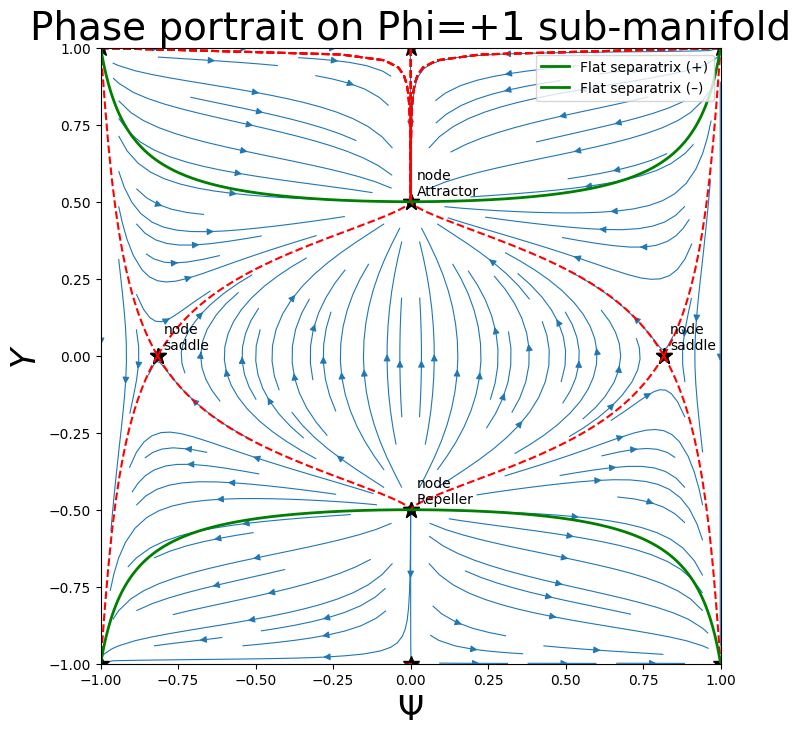

In [3]:
phi = np.linspace(0,5,100)
V0=1
V=V0*(1- np.exp(-np.sqrt(2/3)*phi))**2



def dynamicsStateSpace(Psi,Y):
    #Phi = np.clip(Phi, -0.999, 0.999)
    Psi = np.clip(Psi, -0.999, 0.999)
    Y = np.clip(Y, -0.999, 0.999)
    #dPhi = (1-Phi**2)**(3/2) * Psi/((1-Psi**2 + 1e-6)**0.5)  
    dPsi = -3*Psi*(1-Psi**2)*Y / np.sqrt(1-Y**2)
    dY = (1-Y**2)**(3/2) *(-Y**2/(1-Y**2) -1/6 * Psi**2/(1-Psi**2) +1/3  )
    #dY = -Y**2 * (1-Y**2)**0.5 -1/6 * Psi**2/(1-Psi**2) *(1-Y**2)**(3/2) + 1/3 * (1-Y**2)**(3/2)
    return dPsi, dY


#initialState = np.array([0.9, 0.1])
simulationTime=np.linspace(0,50,600)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory

#plotting phase portrait 
def phase_plot():
  #solutionState=odeint(lambda X,N: dynamicsStateSpace(X[0],X[1]),initialState,simulationTime,rtol=1e-10,atol=1e-10,mxstep=500)
  

  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-0.999,0.999,100)
  x1 = np.linspace(-0.999,0.999,100)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1 or abs(X1[i,j]) >= 1:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = dynamicsStateSpace(X0[i,j], X1[i,j])
                  dX0[i,j] = dx
                  dX1[i,j] = dy
  
  guesses = np.linspace(-0.9,0.9,20) # a range of starting point guesses (20x20 between -0.9,-0.9 and 0.9,0.9 avoiding boundaries)
  # this is a starting point the numerical solver can start from and integrate forwards to a fp / until Psi' or Y' =0
  FP = []

  for gx in guesses:
    for gy in guesses:
      sol = root(lambda X: dynamicsStateSpace(X[0], X[1]), [gx,gy])
      if sol.success:
            Psi_FP, Y_FP = sol.x

            if abs(Psi_FP) < 1 and abs(Y_FP) < 1:
                  FP.append([Psi_FP,Y_FP])
  FP = np.unique(np.round(FP,6),axis=0).tolist()
  FP_boundary = [[1,1],[1,-1],[-1,1],[-1,-1],[0,1],[0,-1]]
  FP = FP + FP_boundary 
  print("Detected fixed points:",FP)


  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)


  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    if abs(x_c) >= 1 or abs(y_c) >= 1:
        starts = [ #  creates 4 points around the FP at the boundary in each quadrant so that atleast 1 is inside the domain
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]
        for start in starts:
                start = np.clip(start,-0.999,0.999) # clip to ensure only plotting trajectories inside the domain
                traj = odeint(lambda X,t: dynamicsStateSpace(X[0],X[1]),start,simulationTime)
                plt.plot(traj[:,0],traj[:,1],'r--')

        continue



    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = dynamicsStateSpace(x_c+eps,y_c)
    fx2 = dynamicsStateSpace(x_c-eps,y_c)

    fy1 = dynamicsStateSpace(x_c,y_c+eps)
    fy2 = dynamicsStateSpace(x_c,y_c-eps)

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12)
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=10)

     # plot separatrices for saddles
    if stability=="saddle":
        delta=1e-6
        for vec,val in zip(eigvecs.T,eigvals):
                for pm in [-1,1]:
                    start = np.array([x_c,y_c]) + pm*delta*vec
                    start = np.clip(start,-0.999,0.999)
                    if val>0:
                        tspan=simulationTime
                    else:
                        tspan=-simulationTime

                    traj=odeint(lambda X,t:
                        dynamicsStateSpace(X[0],X[1]),
                        start,tspan)

                    plt.plot(traj[:,0],traj[:,1],'r--')
    
  Psi_vals = np.linspace(-0.999,0.999,500)
  Y_vals   = np.linspace(-0.999,0.999,500)
  Y_plus  = Y_flat(Psi_vals)
  Y_minus = -Y_flat(Psi_vals)
  plt.plot(Psi_vals, Y_plus,  color='green', lw=2, label='Flat separatrix (+)')
  plt.plot(Psi_vals, Y_minus, color='green', lw=2, label='Flat separatrix (–)')
  
  plt.xlabel(r"$\Psi$",fontsize=24)
  plt.ylabel(r"$Y$",fontsize=24)
  plt.title(rf"Phase portrait on Phi=+1 sub-manifold",fontsize=28)
  plt.xlim(-1,1)
  plt.ylim(-1,1)


  plt.legend()
  
  plt.show()


def Y_flat(Psi):
    eps = 1e-6
    Psi = np.clip(Psi, -1+eps, 1-eps)

    A = (1/3)*(1 + 0.5 * Psi**2/(1 - Psi**2 + eps))

    return np.sqrt(A / (1 + A))









phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


### 3D Plot $\Psi ~vs~ \Phi~ vs ~Y$

IC 0: (-0.99, 0, -0.99) → lengths = 7999, 7999, 7999
IC 1: (-0.99, 0, 0.99) → lengths = 7999, 7999, 7999
IC 2: (-0.2, 0.2, 0.2) → lengths = 7999, 7999, 7999
IC 3: (-0.2, -0.2, -0.2) → lengths = 7999, 7999, 7999
IC 4: (-0.5, 0, 0) → lengths = 7999, 7999, 7999
IC 5: (0.5, -0.7, 0.1) → lengths = 7999, 7999, 7999
IC 6: (-0.995, -0.705, 0) → lengths = 7999, 7999, 7999
IC 7: (-0.995, 0.705, 0) → lengths = 7999, 7999, 7999
IC 8: (-0.995, 0.001, 0.995) → lengths = 7999, 7999, 7999
IC 9: (-0.995, 0.001, -0.995) → lengths = 7999, 7999, 7999
IC 10: (-0.001, 0.001, -0.995) → lengths = 7999, 7999, 7999
IC 11: (-0.001, 0.001, 0.9995) → lengths = 7999, 7999, 7999
IC 12: (-0.6, -0.5, 0.9) → lengths = 7999, 7999, 7999
IC 13: (-0.6, 0.5, -0.9) → lengths = 7999, 7999, 7999


NameError: name 'Phi' is not defined

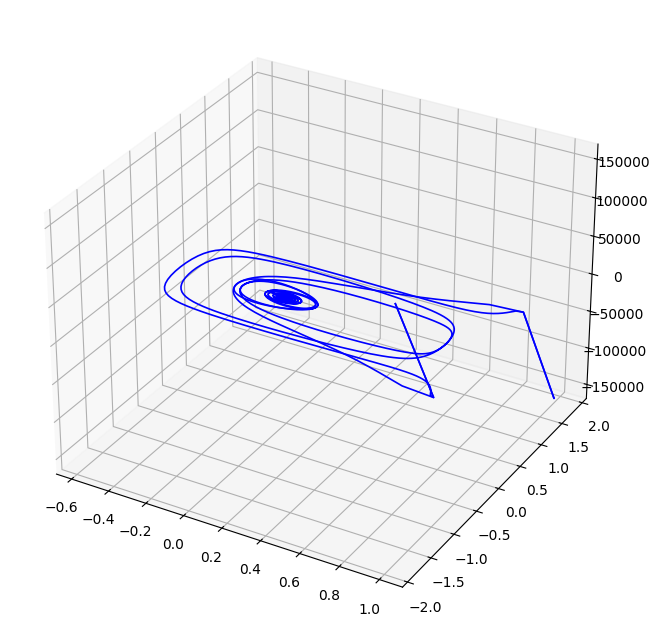

In [4]:
def dynamicsStateSpace(t, X):
    Phi, Psi, Y = X

    # Clipping to avoid singularities
    Phi = np.clip(Phi, -1+1e-6, 1-1e-6)
    Psi = np.clip(Psi, -1+1e-6, 1-1e-6)
    Y   = np.clip(Y,   -1+1e-6, 1-1e-6)

    phi = Phi / np.sqrt(1 - Phi**2)
    exp_phi = np.exp(-np.sqrt(2/3)*phi)

    dPhi = (1 - Phi**2)**1.5 * Psi/ np.sqrt(1 - Psi**2)
    dPsi = -3 * Y * Psi * (1 - Psi**2) / np.sqrt(1 - Y**2)  - 2*(2/3)**0.5 * (1 - Psi**2)**1.5 * exp_phi * (1- exp_phi )
    dY   = (1-Y**2)**0.5 *(-Y**2/(1-Y**2) -1/6 * Psi**2/(1-Psi**2) +1/3 *(1-exp_phi)**2   )
    return [dPhi, dPsi, dY]


def phase_plot(Phi0, Psi0, Y0, T=200, npts=4000):
    y0 = [float(Phi0), float(Psi0), float(Y0)]

    t_forward  = np.linspace(0,  T, npts)
    t_backward = np.linspace(0, -T, npts)

    sol_f = solve_ivp(dynamicsStateSpace, (0,  T), y0, t_eval=t_forward,
                      rtol=1e-9, atol=1e-12, max_step=0.5)

    sol_b = solve_ivp(dynamicsStateSpace, (0, -T), y0, t_eval=t_backward,
                      rtol=1e-9, atol=1e-12, max_step=0.5)

    # combine backward + forward (excluding duplicate t=0)
    Phi = np.concatenate((sol_b.y[0][::-1], sol_f.y[0][1:]))
    Psi = np.concatenate((sol_b.y[1][::-1], sol_f.y[1][1:]))
    Y   = np.concatenate((sol_b.y[2][::-1], sol_f.y[2][1:]))

    return Phi, Psi, Y



# ---------------------------------------------------------
# Build the 14 trajectories (matching Mathematica ICs)
# ---------------------------------------------------------
ICs = [
    (-0.99, 0,    -0.99),
    (-0.99, 0,     0.99),
    (-0.2,  0.2,   0.2),
    (-0.2, -0.2,  -0.2),
    (-0.5,  0,     0),
    ( 0.5, -0.7,   0.1),
    (-0.995, -0.705, 0),
    (-0.995,  0.705, 0),
    (-0.995,  0.001, 0.995),
    (-0.995,  0.001, -0.995),
    (-0.001,  0.001, -0.995),
    (-0.001,  0.001,  0.9995),
    (-0.6,   -0.5,   0.9),
    (-0.6,    0.5,  -0.9),
]

solutions = []
for i, ic in enumerate(ICs):
    sol = phase_plot(*ic)

    Phi_arr, Psi_arr, Y_arr = sol
    print(f"IC {i}: {ic} → lengths = {len(Phi_arr)}, {len(Psi_arr)}, {len(Y_arr)}")

    if len(Phi_arr) < 3:
        print(f" Trajectory FAILED for IC index {i}: {ic}")

    solutions.append(sol)



# ---------------------------------------------------------
# 3D trajectory plotting helper (with arrowhead)
# ---------------------------------------------------------
def plot_trajectory(ax, sol, color='black'):
    Phi_arr, Psi_arr, Y_arr = sol

    if len(Phi_arr) < 3:
        print("Skipping trajectory: too few points")
        return

    ax.plot(Phi_arr, Psi_arr, Y_arr, color=color, lw=1.2)

    # arrowhead
    x0, y0, z0 = Phi_arr[-2], Psi_arr[-2], Y_arr[-2]
    dx, dy, dz = Phi_arr[-1]-Phi_arr[-2], Psi_arr[-1]-Psi_arr[-2], Y_arr[-1]-Y_arr[-2]

    ax.quiver(x0, y0, z0, dx, dy, dz,
              length=0.1, normalize=True, color=color)


# ---------------------------------------------------------
# Plot selected trajectories + flat Friedmann surface
# ---------------------------------------------------------
fig = plt.figure(figsize=(9,8))
ax = fig.add_subplot(111, projection='3d')

# choose which trajectories to show (3–6 in Mathematica)
for idx in [2,3,4,5]:
    plot_trajectory(ax, solutions[idx], color='blue')

# flat Friedmann surface (already computed earlier)
ax.plot_surface(Phi, Psi, Y_plus,  color='green', alpha=0.2, linewidth=0)
ax.plot_surface(Phi, Psi, Y_minus, color='green', alpha=0.2, linewidth=0)

# fixed points
#for p in fixed_points:
#    ax.scatter(float(p[0]), float(p[1]), float(p[2]),
#               color='black', s=40)

ax.set_xlabel(r"$\Phi$")
ax.set_ylabel(r"$\Psi$")
ax.set_zlabel(r"$Y$")
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.tight_layout()
plt.show()
